In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
pio.renderers.default="svg"

In [71]:
raw_dataset=pd.read_csv("Zomato Chennai Listing 2020.csv")
raw_dataset

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [72]:
raw_dataset.shape

(12032, 12)

In [73]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [74]:
raw_dataset.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [75]:
raw_dataset.isnull().sum()

Zomato URL                  0
Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [76]:
raw_dataset[raw_dataset['Dining Rating'].isnull()]

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,https://www.zomato.com/chennai/bai-veetu-kalya...,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,NaN,Does not offer Dining,4.3,1061,['Home Delivery']
77,https://www.zomato.com/chennai/al-dhareeq-beef...,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],300.0,NaN,Does not offer Dining,3.9,19600,['Home Delivery']
106,https://www.zomato.com/chennai/twilight-take-o...,Twilight Take Out,"1, Park Side Street, Lake Area, Nungambakkam,...",Nungambakkam,"['North Indian', ' Chinese', ' Rolls', ' Conti...","['Club Sandwich', ' Chicken Tikka Roll', ' Chi...",350.0,NaN,Does not offer Dining,4.0,11200,"['Home Delivery', 'Free Parking']"
107,https://www.zomato.com/chennai/the-red-box-ann...,The Red Box,"Flat 51/C, Shanthi Colony Main Road, Anna Nag...",Anna Nagar West,['Chinese'],"['Noodle', ' Chilli Chicken Gravy', ' Dragon C...",200.0,NaN,Does not offer Dining,4.2,11500,['Home Delivery']
114,https://www.zomato.com/chennai/charminar-biriy...,Charminar Biriyani Centre,"91, Dr. Besant Road, Near Meesapet Market, Ro...",Royapettah,"['Biryani', ' North Indian']","['Chicken Biryani', ' Bread Halwa', ' Brinjal ...",300.0,NaN,Does not offer Dining,3.9,652,"['Home Delivery', 'Standing Tables']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [77]:
#raw_dataset=raw_dataset.dropna(subset=['Delivery Rating'])

In [78]:
#raw_dataset=raw_dataset.dropna(subset=['Dining Rating'])

In [79]:
raw_dataset['Delivery Rating'].isnull().sum()

np.int64(5851)

In [80]:
raw_dataset['Dining Rating'].isnull().sum()

np.int64(5351)

In [81]:
raw_dataset

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [82]:
raw_dataset.drop(['Zomato URL','Address'],axis=1,inplace=True)

In [83]:
raw_dataset

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [84]:
raw_dataset[raw_dataset['Top Dishes']=='Invalid']

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
72,Deen Biriyani,Aminijikarai,"['Biryani', ' South Indian', ' North Indian', ...",Invalid,500.0,3.9,460,3.8,18,"['Home Delivery', 'Indoor Seating']"
240,Smoke Hub Barbeque,Velachery,"['BBQ', ' Asian', ' North Indian', ' Desserts'...",Invalid,1500.0,4.3,867,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Serves Halal', 'Gaming Area..."
291,Nellai Fast Food,Thousand Lights,"['Chinese', ' Biryani', ' North Indian']",Invalid,300.0,4.0,366,3.8,24200,"['Breakfast', 'Home Delivery', 'Indoor Seating']"
294,Hunger Palato,Medavakkam,"['Momos', ' Steak', ' Burger']",Invalid,350.0,3.9,128,3.9,44,"['Breakfast', 'Home Delivery', 'Outdoor Seatin..."
436,Kebab@Lake Street,Velachery,"['Kebab', ' Mughlai', ' Chinese', ' Biryani']",Invalid,500.0,4.0,266,3.8,10300,"['Home Delivery', 'Catering Available', 'Free ..."
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [85]:
raw_dataset['Top Dishes']=raw_dataset['Top Dishes'].replace(to_replace='Invalid',value='NA',regex=True)

In [86]:
raw_dataset

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],NA,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],NA,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],NA,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],NA,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [42]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          6681 non-null   float64
 6   Dining Rating Count    11812 non-null  object 
 7   Delivery Rating        6181 non-null   float64
 8   Delivery Rating Count  11812 non-null  object 
 9   Features               12032 non-null  object 
dtypes: float64(3), object(7)
memory usage: 940.1+ KB


In [87]:
#raw_dataset['Cuisine']=raw_dataset['Cuisine'].astype('string')
#raw_dataset['Dining Rating Count']=raw_dataset['Dining Rating Count'].astype('int64')
#raw_dataset['Delivery Rating Count']=raw_dataset['Delivery Rating Count'].astype('int64')

In [88]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          6681 non-null   float64
 6   Dining Rating Count    11812 non-null  object 
 7   Delivery Rating        6181 non-null   float64
 8   Delivery Rating Count  11812 non-null  object 
 9   Features               12032 non-null  object 
dtypes: float64(3), object(7)
memory usage: 940.1+ KB


In [89]:
raw_dataset[raw_dataset.duplicated()]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
9103,Brownie Heaven,T. Nagar,"['Bakery', ' Desserts', ' Beverages']",NA,350.0,NaN,Not enough Dining Reviews,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
9995,ibaco,Kanchipuram District,['Ice Cream'],NA,200.0,NaN,Not enough Dining Reviews,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
10534,Cake Waves,Thiruvallur,"['Bakery', ' Fast Food']",NA,500.0,NaN,Not enough Dining Reviews,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
11225,Pizza Square,Thiruvanmiyur,"['Pizza', ' Fast Food']",NA,300.0,NaN,Not enough Dining Reviews,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating']"
11361,Aavin Parlour,George Town,['Ice Cream'],NA,200.0,NaN,Not enough Dining Reviews,NaN,Does not offer Delivery,"['Takeaway Only', 'Desserts and Bakes']"
11390,The Cake Point,Mogappair,['Bakery'],NA,200.0,NaN,Not enough Dining Reviews,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
11489,Parantha Pundit,Mogappair,"['North Indian', ' Beverages']",NA,200.0,NaN,Does not offer Dining,NaN,Not enough Delivery Reviews,['Delivery Only']
11496,Parantha Pundit,Kovalam,"['North Indian', ' Beverages']",NA,200.0,NaN,Does not offer Dining,NaN,Not enough Delivery Reviews,['Delivery Only']
11553,Leo Coffee,Mylapore,"['Coffee', ' Tea', ' Beverages']",NA,250.0,NaN,Does not offer Dining,NaN,Not enough Delivery Reviews,['Home Delivery']
11572,Leo Coffee,Anna Nagar East,"['Coffee', ' Tea', ' Beverages']",NA,250.0,NaN,Not enough Dining Reviews,NaN,Does not offer Delivery,"['Takeaway Only', 'Vegetarian Only']"


In [90]:
zomato_ch_df=raw_dataset.copy()

In [91]:
zomato_ch_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


#Exploratory Data Analysis  
#1. HOW MANY RESTAURANTS ARE IN CHENNAI FOR EACH CUSINE TYPE?

In [92]:
zomato_ch_df['Cuisine']=zomato_ch_df['Cuisine'].apply(eval)
cuisine_df=zomato_ch_df.explode('Cuisine')

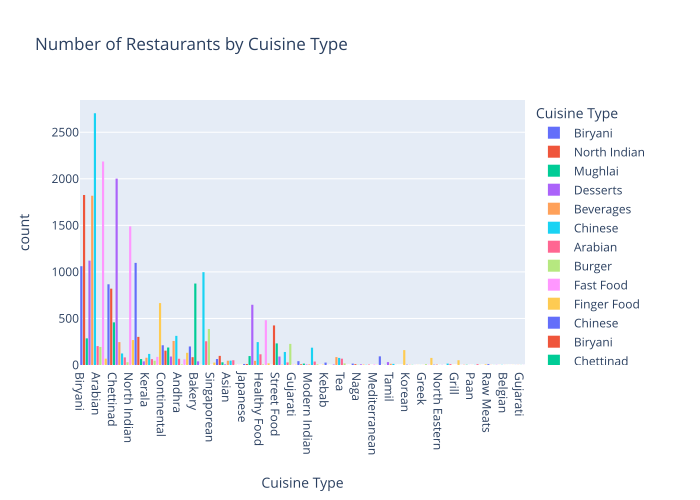

In [94]:
fig=px.histogram(cuisine_df,x='Cuisine',color='Cuisine',
                 title="Number of Restaurants by Cuisine Type",
                 labels={"Cuisine": "Cuisine Type"})
fig.show()

#2. How to categorize the restaurants in chennai with the rating type?

In [95]:
delivery_rating_df=zomato_ch_df['Delivery Rating'].value_counts().reset_index()
delivery_rating_df.rename(columns={'Delivery Rating':'Delivery Rating','Count':'Count'}, inplace=True) 
delivery_rating_df

,Delivery Rating,count
0,3.9,1383
1,3.8,701
2,4.0,570
3,3.7,559
4,4.1,468
5,3.6,465
6,4.2,401
7,3.5,314
8,4.3,277
9,3.4,259


In [96]:
delivery_rating_type=[]
def find_delrating_type(delivery_rating_df):

    
    delrating=delivery_rating_df['Delivery Rating']
    n_num=delivery_rating_df.shape[0]

    for i in range (n_num):
    
        if delrating[i]<3:
            delivery_rating_type.append("Very Poor")
        if delrating[i]>=3 and delrating[i]<3.5:
            delivery_rating_type.append("Poor")
        if delrating[i]>=3.5 and delrating[i]<4:
            delivery_rating_type.append("Good")
        if delrating[i]>=4 and delrating[i]<4.5:
            delivery_rating_type.append("Very Good")
        if delrating[i]>=4.5 and delrating[i]<=5:
            delivery_rating_type.append("Excellent")
    
    return delivery_rating_type
    

In [97]:
find_delrating_type(delivery_rating_df)

['Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Poor',
 'Poor',
 'Very Good',
 'Poor',
 'Poor',
 'Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Very Poor']

In [98]:
delivery_rating_ty=pd.DataFrame(delivery_rating_type,columns=['Rating Category'])
delivery_rate_cate=pd.concat([delivery_rating_df,delivery_rating_ty],axis=1)
delivery_rate_cate=delivery_rate_cate.reindex(columns=['Delivery Rating','Rating Category','count'])
del_rate_cate_gp=delivery_rate_cate['Rating Category'].value_counts()
del_rate_cate_gp

Rating Category
Very Poor    14
Good          5
Very Good     5
Poor          5
Excellent     3
Name: count, dtype: int64

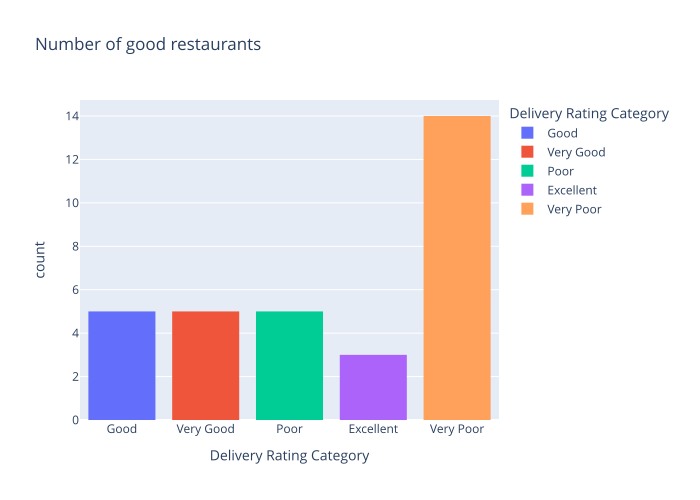

In [99]:
fig=px.histogram(delivery_rate_cate,x=delivery_rate_cate['Rating Category'],color='Rating Category',
                 title="Number of good restaurants",
                labels={"Rating Category":"Delivery Rating Category"})
fig.show()

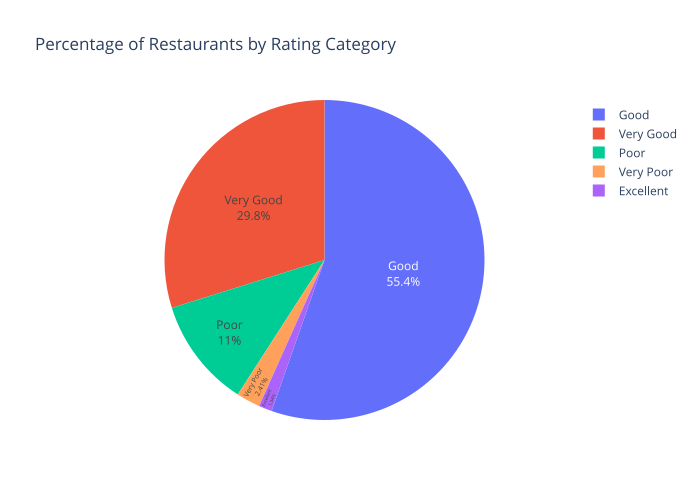

In [103]:
fig = px.pie(delivery_rate_cate, names='Rating Category', values='count', color='Rating Category', 
             title='Percentage of Restaurants by Rating Category').update_traces(textposition='inside', textinfo='percent+label')
fig.show() 